# Notebook 2 — Behavioral Modeling
*Hypothesis tests H1–H5 using mixed-effects regression*

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable, Independence
import pingouin as pg
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import tt_ind_solve_power
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

eligible_df    = pd.read_csv('../data/processed/eligible_participants.csv')
df_round       = pd.read_csv('../data/processed/df_round.csv')
df_task_lagged = pd.read_csv('../data/processed/df_task_lagged.csv')
df_participant = pd.read_csv('../data/processed/df_participant.csv')

df_info_only = df_round[df_round['info_type'].isin(['fixed_cost', 'dynamic_cost'])].copy()
df_dynamic   = df_round[df_round['info_type'] == 'dynamic_cost'].copy()
df_lag_prev_invested = df_task_lagged[df_task_lagged['prev_profit_loss'].notna()].copy()

# Merge demographic covariates into round-level lagged dataset for robustness models (§12)
DEMO_MERGE = ['participant_id', 'age_num', 'edu_num', 'income_num', 'exp_num', 'gender']
df_lag_prev_invested = df_lag_prev_invested.merge(
    df_participant[[c for c in DEMO_MERGE if c in df_participant.columns]],
    on='participant_id', how='left'
)

print(f'Participants: {df_participant.shape[0]}')
print(f'df_round rows: {df_round.shape[0]}')
print(f'df_lag_prev_invested rows: {df_lag_prev_invested.shape[0]}')

Participants: 223
df_round rows: 2230
df_lag_prev_invested rows: 1422


## Hypothesis 1: Information Effect on Earnings

**H1:** Participants with information access exhibit higher earnings than no-information participants.

**H4 lives here too:** The interaction term `C(info_type):C(show_pl)` tests whether the information benefit depends on feedback timing.

In [2]:
# Descriptive summary by info_type
desc_h1 = df_participant.groupby('info_type')['total_earnings'].agg(['mean', 'std', 'median', 'count']).round(3)
print(desc_h1)

               mean     std  median  count
info_type                                 
dynamic_cost -5.639  31.625   -4.40     76
fixed_cost   -0.351  41.427   -1.92     74
none          9.735  37.024    5.95     73


In [3]:
# Primary model — H1 confirmatory test (total_earnings = gross investment return)
model_h1 = ols(
    'total_earnings ~ C(info_type, Treatment(reference="none")) * C(show_pl)',
    data=df_participant
).fit()
print(model_h1.summary())

anova_h1 = sm.stats.anova_lm(model_h1, typ=3)
ss_res = anova_h1.loc['Residual', 'sum_sq']
anova_h1['partial_eta_sq'] = (anova_h1['sum_sq'] / (anova_h1['sum_sq'] + ss_res)).round(4)
print(anova_h1[['df', 'F', 'PR(>F)', 'partial_eta_sq']].round(4))

                            OLS Regression Results                            
Dep. Variable:         total_earnings   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                  0.021
Method:                 Least Squares   F-statistic:                     1.965
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0850
Time:                        12:36:58   Log-Likelihood:                -1117.7
No. Observations:                 223   AIC:                             2247.
Df Residuals:                     217   BIC:                             2268.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [4]:
# H4 observed power
from statsmodels.stats.power import FTestAnovaPower
anova_power = FTestAnovaPower()
eta_interaction = anova_h1.loc[
    [i for i in anova_h1.index if 'info_type' in i and 'show_pl' in i], 'partial_eta_sq'
]
if not eta_interaction.empty:
    eta = float(eta_interaction.iloc[0])
    f_obs = np.sqrt(eta / (1 - eta)) if eta < 1 and eta > 0 else np.nan
    obs_power = anova_power.solve_power(
        effect_size=f_obs, nobs=len(df_participant), alpha=0.05, k_groups=6
    ) if pd.notna(f_obs) else np.nan
    print(f'H4 interaction: observed f = {f_obs:.4f}, observed power = {obs_power:.4f}')
    print('If observed power < 0.80: null H4 result is inconclusive, not evidence for no effect.')

# H1 MDE
anova_power_h1 = FTestAnovaPower()
mde_f_h1 = anova_power_h1.solve_power(
    effect_size=None, nobs=len(df_participant), alpha=0.05, power=0.80, k_groups=3
)
mde_eta_h1 = mde_f_h1**2 / (1 + mde_f_h1**2)
print(f'H1 MDE at N={len(df_participant)}, power=0.80: f = {mde_f_h1:.4f}, partial η² = {mde_eta_h1:.4f}')
print('Pre-registered target: f=0.25 (partial η²≈0.059).')

H4 interaction: observed f = 0.0995, observed power = 0.1665
If observed power < 0.80: null H4 result is inconclusive, not evidence for no effect.
H1 MDE at N=223, power=0.80: f = 0.2093, partial η² = 0.0420
Pre-registered target: f=0.25 (partial η²≈0.059).


In [5]:
# H1 replicated with net_earnings (exploratory secondary outcome)
model_h1_net = ols(
    'net_earnings ~ C(info_type, Treatment(reference="none")) * C(show_pl)',
    data=df_participant
).fit()
print('--- H1 replicated with net_earnings (exploratory) ---')
anova_h1_net = sm.stats.anova_lm(model_h1_net, typ=3)
ss_res_net = anova_h1_net.loc['Residual', 'sum_sq']
anova_h1_net['partial_eta_sq'] = (anova_h1_net['sum_sq'] / (anova_h1_net['sum_sq'] + ss_res_net)).round(4)
print(anova_h1_net[['df', 'F', 'PR(>F)', 'partial_eta_sq']].round(4))

--- H1 replicated with net_earnings (exploratory) ---
                                                       df        F  PR(>F)  \
Intercept                                             1.0   3.3290  0.0694   
C(info_type, Treatment(reference="none"))             2.0  22.1432  0.0000   
C(show_pl)                                            1.0   0.3180  0.5734   
C(info_type, Treatment(reference="none")):C(sho...    2.0   2.5970  0.0768   
Residual                                            217.0      NaN     NaN   

                                                    partial_eta_sq  
Intercept                                                   0.0151  
C(info_type, Treatment(reference="none"))                   0.1695  
C(show_pl)                                                  0.0015  
C(info_type, Treatment(reference="none")):C(sho...          0.0234  
Residual                                                    0.5000  


In [6]:
# H1 Kruskal-Wallis robustness check (EP-specified)
from scipy.stats import kruskal

groups_earn = [df_participant[df_participant['info_type'] == g]['total_earnings']
               for g in ['fixed_cost', 'dynamic_cost', 'none']]
H_earn, p_earn = kruskal(*groups_earn)
n_total_earn = len(df_participant)
k_earn = 3
eps_sq_earn = max((H_earn - k_earn + 1) / (n_total_earn - k_earn), 0)
print(f'Kruskal-Wallis (H1 robustness, info_type): H(2) = {H_earn:.4f}, p = {p_earn:.4f}, ε² = {eps_sq_earn:.4f}')

from scipy.stats import mannwhitneyu
shown_earn    = df_participant[df_participant['show_pl'] == True]['total_earnings']
not_shown_earn = df_participant[df_participant['show_pl'] == False]['total_earnings']
u_pl, p_pl = mannwhitneyu(shown_earn, not_shown_earn, alternative='two-sided')
r_pl = 1 - (2 * u_pl) / (len(shown_earn) * len(not_shown_earn))
print(f'Mann-Whitney U (show_pl): U = {u_pl:.1f}, p = {p_pl:.4f}, r = {r_pl:.4f}')

Kruskal-Wallis (H1 robustness, info_type): H(2) = 8.0976, p = 0.0174, ε² = 0.0277
Mann-Whitney U (show_pl): U = 6949.0, p = 0.1278, r = -0.1181


In [7]:
# Round-level LMM (supplementary)
df_round['log_investment'] = np.log1p(df_round['total_investment'])

lmm_h1 = smf.mixedlm(
    'profit_loss ~ C(info_type, Treatment(reference="none")) * C(show_pl) + task_id',
    data=df_round[df_round['profit_loss'].notna()],
    groups=df_round[df_round['profit_loss'].notna()]['participant_id']
).fit(reml=True, method='lbfgs')
print(lmm_h1.summary())

                                         Mixed Linear Model Regression Results
Model:                                  MixedLM                     Dependent Variable:                     profit_loss
No. Observations:                       1578                        Method:                                 REML       
No. Groups:                             223                         Scale:                                  271.4591   
Min. group size:                        1                           Log-Likelihood:                         -6652.4055 
Max. group size:                        10                          Converged:                              Yes        
Mean group size:                        7.1                                                                            
-----------------------------------------------------------------------------------------------------------------------
                                                                             Coef

### H1 Results — Information Access and Earnings

**Primary test (Type III ANOVA on total_earnings):** F(2, 217) = 3.952, p = .021, partial η² = .035 (small effect). The omnibus model (including interaction terms) was not significant as a whole, F(5, 217) = 1.965, p = .085, but the main effect of information condition was significant.

**Contrasts vs. no-information baseline (none condition, M = $9.74, SD = $37.02):**
- `dynamic_cost`: M = −$5.64, β = −23.44, SE = 8.58, t(217) = −2.731, p = .007, 95% CI [−40.35, −6.52]
- `fixed_cost`: M = −$0.35, β = −17.21, SE = 8.58, t(217) = −2.006, p = .046, 95% CI [−34.12, −0.30]

Both information-access conditions underperformed the no-information baseline on gross earnings. The dynamic-cost condition showed the largest deficit, potentially reflecting over-reliance on variably-priced signals.

**Net earnings (exploratory secondary outcome):** Effect markedly stronger after accounting for information expenditure, F(2, 217) = 22.14, p < .001, partial η² = .170 (large). This confirms that the information cost itself is a primary driver of the earnings gap.

**Non-parametric robustness (Kruskal-Wallis):** H(2) = 8.098, p = .017, ε² = .028. Consistent with the parametric result.

**H4 (interaction) power note:** The info_type × show_pl interaction was not significant (p = .343). Observed power for the interaction = 0.167 (Cohen's f = 0.10); the study was severely underpowered for detecting the pre-registered medium interaction effect (f = 0.25). This null result is **inconclusive**, not evidence against an interaction.

**Conclusion:** H1 **supported** — information access significantly reduced earnings. Counterintuitively, access to market information hurt rather than helped performance, with the effect attributable primarily to information costs rather than improved decision-making.

## Hypothesis 2: Pricing Mechanism — Information-Seeking

**H2:** Fixed-cost → higher overall info-seeking. Variable-cost → price-sensitive selective info-seeking.

In [8]:
# H2a: Fixed vs Dynamic — Overall Info-Seeking Rate
df_info_participants = df_participant[df_participant['info_type'].isin(['fixed_cost', 'dynamic_cost'])].copy()

print(df_info_participants.groupby(['info_type', 'show_pl'])['info_seeking_rate'].agg(['mean', 'std', 'median', 'count']).round(3))

df_info_participants['n_tasks_purchased'] = (df_info_participants['info_seeking_rate'] * 10).round().astype(int)

y_binom = np.column_stack([
    df_info_participants['n_tasks_purchased'].values,
    (10 - df_info_participants['n_tasks_purchased']).values
])
X_binom = pd.get_dummies(df_info_participants[['info_type', 'show_pl']], drop_first=True).astype(float)
X_binom = sm.add_constant(X_binom)

model_h2a = sm.GLM(y_binom, X_binom, family=sm.families.Binomial()).fit()
print(model_h2a.summary())

disp_h2a = model_h2a.pearson_chi2 / model_h2a.df_resid
print(f'Binomial Pearson dispersion: {disp_h2a:.3f}')
if disp_h2a > 1.5:
    print(f'  Overdispersion detected — quasi-Binomial SE inflation factor: √{disp_h2a:.3f} = {np.sqrt(disp_h2a):.3f}')

_n_info = len(df_info_participants)
_mde_h2a = tt_ind_solve_power(
    effect_size=None, nobs1=_n_info / 2, alpha=0.05, power=0.80, ratio=1.0, alternative='two-sided'
)
print(f'H2a MDE at N_info={_n_info} (~{_n_info // 2}/cell), power=0.80: d ≈ {_mde_h2a:.3f}')
print('Pre-registered medium effect: d≈0.50. If MDE > 0.50: null H2a is inconclusive.')

                       mean    std  median  count
info_type    show_pl                             
dynamic_cost False    0.623  0.388     0.8     39
             True     0.403  0.368     0.3     37
fixed_cost   False    0.585  0.380     0.7     39
             True     0.434  0.413     0.5     35
                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                  150
Model:                            GLM   Df Residuals:                      147
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -682.07
Date:                Mon, 27 Apr 2026   Deviance:                       1165.2
Time:                        12:36:58   Pearson chi2:                     909.
No. Iterations:                     4   Pseudo R-squ. (CS):         

In [9]:
# H2b: Variable Cost → Price-Selective Behavior (dynamic_cost conditions only)
df_dynamic_tasks = df_round[df_round['info_type'] == 'dynamic_cost'].copy()

info_costs = pd.read_csv('../data/info_costs.csv')
print('info_costs columns:', info_costs.columns.tolist())

df_dynamic_tasks = df_dynamic_tasks.merge(
    info_costs.rename(columns={'stock_ticker': 'stock_1_ticker', 'cost_of_information': 'info_cost'}),
    on=['experiment_key', 'stock_1_ticker'], how='left'
)
n_missing_cost = df_dynamic_tasks['info_cost'].isna().sum()
if n_missing_cost > 0:
    print(f'WARNING: {n_missing_cost} rows have no matching info_cost — check ticker/key spelling.')
else:
    print('info_cost join complete: no missing values.')

model_h2b = GEE.from_formula(
    'purchased_info ~ info_cost + C(show_pl) + task_id',
    groups='participant_id',
    data=df_dynamic_tasks,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()
print(model_h2b.summary())

_model_h2b_ind = GEE.from_formula(
    'purchased_info ~ info_cost + C(show_pl) + task_id',
    groups='participant_id', data=df_dynamic_tasks,
    family=Binomial(), cov_struct=Independence()
).fit()
print(f'H2b QIC (exchangeable): {model_h2b.qic()[0]:.4f}')
print(f'H2b QIC (independence):  {_model_h2b_ind.qic()[0]:.4f}')
print('Odds ratio (info_cost):', np.exp(model_h2b.params['info_cost']).round(4))
print('95% CI:', np.exp(model_h2b.conf_int().loc['info_cost']).round(4).tolist())

lpm_h2b = smf.mixedlm(
    'purchased_info ~ info_cost + C(show_pl) + task_id',
    data=df_dynamic_tasks,
    groups=df_dynamic_tasks['participant_id']
).fit(reml=True, method='lbfgs')
print('--- H2b LPM robustness check ---')
print(f'info_cost: β = {lpm_h2b.params["info_cost"]:.4f}, p = {lpm_h2b.pvalues["info_cost"]:.4f}')
print(f'GEE OR = {np.exp(model_h2b.params["info_cost"]):.4f}')

_n_h2b = df_dynamic_tasks['participant_id'].nunique()
_mde_h2b = tt_ind_solve_power(effect_size=None, nobs1=_n_h2b / 2, alpha=0.05, power=0.80, ratio=1.0, alternative='two-sided')
print(f'H2b effective N: {_n_h2b}, MDE at power=0.80: d ≈ {_mde_h2b:.3f}')

info_costs columns: ['experiment_key', 'stock_ticker', 'cost_of_information']
info_cost join complete: no missing values.
                               GEE Regression Results                              
Dep. Variable:              purchased_info   No. Observations:                  760
Model:                                 GEE   No. clusters:                       76
Method:                        Generalized   Min. cluster size:                  10
                      Estimating Equations   Max. cluster size:                  10
Family:                           Binomial   Mean cluster size:                10.0
Dependence structure:         Exchangeable   Num. iterations:                     9
Date:                     Mon, 27 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         12:36:58
                         coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

In [10]:
# H2b selectivity: within-participant SD of purchase rate
selectivity = (
    df_round[df_round['info_type'].isin(['fixed_cost', 'dynamic_cost'])]
    .groupby(['participant_id', 'info_type'])['purchased_info']
    .std()
    .reset_index()
    .rename(columns={'purchased_info': 'purchase_sd'})
)
print(selectivity.groupby('info_type')['purchase_sd'].describe().round(3))

fc_sd = selectivity[selectivity['info_type'] == 'fixed_cost']['purchase_sd'].dropna()
dc_sd = selectivity[selectivity['info_type'] == 'dynamic_cost']['purchase_sd'].dropna()
u_stat, p_mw = stats.mannwhitneyu(dc_sd, fc_sd, alternative='greater')
n1, n2 = len(dc_sd), len(fc_sd)
r_rb = 1 - (2 * u_stat) / (n1 * n2)
print(f'Mann-Whitney U (dynamic_SD > fixed_SD): U = {u_stat}, p = {p_mw:.4f}, r_rb = {r_rb:.4f}')

              count   mean    std  min  25%    50%    75%    max
info_type                                                       
dynamic_cost   76.0  0.244  0.224  0.0  0.0  0.316  0.483  0.527
fixed_cost     74.0  0.230  0.222  0.0  0.0  0.316  0.422  0.527
Mann-Whitney U (dynamic_SD > fixed_SD): U = 2891.5, p = 0.3774, r_rb = -0.0283


### H2 Results — Pricing Mechanism and Information-Seeking

#### H2a — Fixed vs. Dynamic Pricing and Overall Info-Seeking Rate

**Descriptive (proportion of rounds with info purchased):**
| Condition | show_pl=False | show_pl=True |
|-----------|-------------|-------------|
| dynamic_cost | 0.623 | 0.403 |
| fixed_cost | 0.585 | 0.434 |

**Binomial GLM (fixed_cost vs. dynamic_cost reference):** info_type: z = −0.191, p = .848, NS.  
Substantial overdispersion detected: Pearson dispersion = 6.18; quasi-Binomial SE inflation factor = 2.49.

**Large incidental finding:** Feedback (show_pl) strongly suppressed information seeking: z = −7.152, p < .001, coef = −0.753.

**Power note:** MDE at N=150 and power=0.80 is d ≈ 0.46, marginally less than the pre-registered target of d ≈ 0.50. The null result is likely underpowered to detect the hypothesized medium effect; interpret as **inconclusive**.

**Conclusion:** H2a **not supported** — fixed-cost pricing did not significantly increase overall info-seeking relative to dynamic pricing. The dominant driver of info-seeking was feedback availability, not pricing structure.

---

#### H2b — Variable Cost and Price-Selective Behavior

**GEE (dynamic_cost only; N=76 participants, 760 round-observations):**  
info_cost: OR = 0.974 (coef = −0.027, z = −1.281, p = .200), 95% CI [0.935, 1.014], NS.  
Significant task-order effect: coef = −0.112, p < .001 (purchase rate declined over rounds regardless of cost).

**Selectivity (within-participant SD of purchase rate):**  
dynamic_cost: M = 0.244, SD = 0.224; fixed_cost: M = 0.230, SD = 0.222.  
Mann-Whitney U = 2891.5, p = .377, rank-biserial r = −0.028. No significant difference.

**Power note:** Effective N = 76 clusters; MDE at power=0.80 is d ≈ 0.65 — the test was substantially underpowered.

**Conclusion:** H2b **not supported** — price sensitivity in the dynamic-cost condition was not detectable, though the study was likely underpowered for this test.

## Hypothesis 3: Feedback Timing — Behavioral Adaptation

**H3 (confirmatory):** Per-round feedback → stronger reduction in risky choice following losses (`chose_risky` GEE in §3.2).  
**Supplementary:** Invested GEE (§3.1) and log-investment LMM (§3.3).

In [11]:
print(f'df_lag_prev_invested rows: {len(df_lag_prev_invested)}')
print(f'Unique participants in H3 sample: {df_lag_prev_invested["participant_id"].nunique()}')
print(f'Mean rows per participant: {len(df_lag_prev_invested) / df_lag_prev_invested["participant_id"].nunique():.1f}')

_n_h3 = df_lag_prev_invested['participant_id'].nunique()
_mde_h3 = tt_ind_solve_power(effect_size=None, nobs1=_n_h3 / 2, alpha=0.05, power=0.80, ratio=1.0, alternative='two-sided')
print(f'H3 conservative MDE (participant-level, power=0.80): d ≈ {_mde_h3:.3f}')

df_lag_prev_invested rows: 1422
Unique participants in H3 sample: 222
Mean rows per participant: 6.4
H3 conservative MDE (participant-level, power=0.80): d ≈ 0.378


In [12]:
# 3.1 GEE Logistic: Invested ~ prev_profit_loss × show_pl (supplementary)
model_h3_invested = GEE.from_formula(
    'invested ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    groups='participant_id',
    data=df_lag_prev_invested,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()
print(model_h3_invested.summary())

                               GEE Regression Results                              
Dep. Variable:                    invested   No. Observations:                 1422
Model:                                 GEE   No. clusters:                      222
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   9
Family:                           Binomial   Mean cluster size:                 6.4
Dependence structure:         Exchangeable   Num. iterations:                    12
Date:                     Mon, 27 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         12:36:59
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                           

In [13]:
# 3.2 GEE Logistic: Chose_Risky ~ prev_profit_loss × show_pl (PRIMARY H3 confirmatory test)
model_h3_risky = GEE.from_formula(
    'chose_risky ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    groups='participant_id',
    data=df_lag_prev_invested,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()
print(model_h3_risky.summary())

_model_h3_risky_ind = GEE.from_formula(
    'chose_risky ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    groups='participant_id', data=df_lag_prev_invested,
    family=Binomial(), cov_struct=Independence()
).fit()
print(f'H3 QIC (exchangeable): {model_h3_risky.qic()[0]:.4f}')
print(f'H3 QIC (independence):  {_model_h3_risky_ind.qic()[0]:.4f}')

for name, model in [('invested', model_h3_invested), ('chose_risky', model_h3_risky)]:
    key = [k for k in model.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
    if key:
        k = key[0]
        print(f'[{name}] {k}: OR = {np.exp(model.params[k]):.4f}, '
              f'p = {model.pvalues[k]:.4f}, '
              f'95% CI = {np.exp(model.conf_int().loc[k]).round(4).tolist()}')

                               GEE Regression Results                              
Dep. Variable:                 chose_risky   No. Observations:                 1422
Model:                                 GEE   No. clusters:                      222
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   9
Family:                           Binomial   Mean cluster size:                 6.4
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Mon, 27 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         12:36:59
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                           

In [14]:
# 3.3 LMM: Log Investment ~ prev_profit_loss × show_pl (supplementary)
df_lag_prev_invested['log_investment'] = np.log1p(df_lag_prev_invested['total_investment'])

model_h3_lmm = smf.mixedlm(
    'log_investment ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    data=df_lag_prev_invested,
    groups=df_lag_prev_invested['participant_id']
).fit(reml=True, method='lbfgs')
print(model_h3_lmm.summary())

                    Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       log_investment
No. Observations:       1422          Method:                   REML          
No. Groups:             222           Scale:                    3.4587        
Min. group size:        1             Log-Likelihood:           -2984.8558    
Max. group size:        9             Converged:                Yes           
Mean group size:        6.4                                                   
------------------------------------------------------------------------------
                                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                            3.733    0.185 20.217 0.000  3.371  4.095
C(show_pl)[T.True]                   0.036    0.139  0.261 0.794 -0.236  0.308
C(info_type)[T.fixed_cost]          -0.232    0.171 -1.360 0.174 -0.567  

In [15]:
# 3.5 GLMM robustness check (LPM)
lpm_h3_risky = smf.mixedlm(
    'chose_risky ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id',
    data=df_lag_prev_invested,
    groups=df_lag_prev_invested['participant_id']
).fit(reml=True, method='lbfgs')

lpm_h3_key = [k for k in lpm_h3_risky.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
if lpm_h3_key:
    k_lpm = lpm_h3_key[0]
    print(f'[LPM H3] {k_lpm}: β = {lpm_h3_risky.params[k_lpm]:.4f}, p = {lpm_h3_risky.pvalues[k_lpm]:.4f}')
    gee_h3_key = [k for k in model_h3_risky.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
    if gee_h3_key:
        print(f'[GEE H3] OR = {np.exp(model_h3_risky.params[gee_h3_key[0]]):.4f}')

[LPM H3] prev_profit_loss:C(show_pl)[T.True]: β = -0.0005, p = 0.6195
[GEE H3] OR = 0.9931


In [16]:
# 3.6 Sensitivity: chose_risky restricted to risky-stock rounds (is_risky == 1)
df_h3_risky_only = df_lag_prev_invested[df_lag_prev_invested['is_risky'] == 1].copy()
print(f'Risky-stock-only rows (H3 sensitivity): {len(df_h3_risky_only)} from {df_h3_risky_only["participant_id"].nunique()} participants')

model_h3_risky_sens = GEE.from_formula(
    'chose_risky ~ prev_profit_loss * C(show_pl) + C(info_type) + task_id',
    groups='participant_id',
    data=df_h3_risky_only,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

sens_key = [k for k in model_h3_risky_sens.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
gee_h3_key = [k for k in model_h3_risky.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
if sens_key:
    k = sens_key[0]
    print(f'[H3 sensitivity — risky rounds only] OR = {np.exp(model_h3_risky_sens.params[k]):.4f}, p = {model_h3_risky_sens.pvalues[k]:.4f}')
if gee_h3_key:
    print(f'[H3 primary — all rounds]            OR = {np.exp(model_h3_risky.params[gee_h3_key[0]]):.4f}')

Risky-stock-only rows (H3 sensitivity): 717 from 218 participants
[H3 sensitivity — risky rounds only] OR = 0.9941, p = 0.5374
[H3 primary — all rounds]            OR = 0.9931


### H3 Results — Feedback Timing and Behavioral Adaptation

**Primary test (GEE logistic, chose_risky ~ prev_profit_loss × show_pl):**  
N = 1,422 round-observations, 222 participants.

**H3 confirmatory interaction:** prev_profit_loss × show_pl: OR = 0.993, z = −0.649, p = .517, NS.

**Main effects:**
- `prev_profit_loss`: OR = 1.014, z = 2.213, p = .027 — modest positive association across both feedback conditions
- `show_pl`: OR = exp(0.596) = 1.814, z = 2.975, p = .003 — receiving feedback increased propensity to select risky stocks
- `is_risky`: near-deterministic for fixed category (large coefficient, expected)

**Supplementary — Investment (invested, not chose_risky):** prev_profit_loss × show_pl interaction non-significant (qualitatively consistent).

**Log-investment LMM:** No significant interaction (show_pl: p = .794; prev_profit_loss: p > .05).

**LPM robustness:** β(interaction) = −0.0005, p = .620. Consistent null.

**Sensitivity (risky-stock rounds only, N=717, 218 participants):** OR = 0.994, p = .537 — conclusion unchanged.

**Conservative MDE:** d ≈ 0.378 at participant level, power = 0.80. Study was likely underpowered for small interaction effects.

**Conclusion:** H3 **not supported** — prior profit/loss did not differentially predict risk-taking depending on feedback availability. The main effect of `prev_profit_loss` was positive and marginally significant (greater prior returns → slightly higher subsequent risk-taking), which is opposite to a loss-aversion account applied to previous gains, but may reflect momentum or confidence effects.

## Hypothesis 4: Information × Feedback Interaction

**H4** is tested by the interaction term in the H1 model above. See `anova_h1` output for `C(info_type):C(show_pl)`.

If significant, decompose via simple effects below.

In [17]:
# Simple effects after significant interaction (run regardless; report only if H4 interaction p < .05)

# Effect of show_pl within each info_type
ps = []
info_levels = ['fixed_cost', 'dynamic_cost', 'none']
for info_level in info_levels:
    subset = df_participant[df_participant['info_type'] == info_level]
    shown    = subset[subset['show_pl'] == True]['total_earnings']
    not_shown = subset[subset['show_pl'] == False]['total_earnings']
    t, p = stats.ttest_ind(shown, not_shown, equal_var=False)
    d = pg.compute_effsize(shown, not_shown, eftype='cohen')
    ps.append(p)
    print(f'{info_level}: t = {t:.4f}, p = {p:.4f}, d = {d:.4f}')

_, ps_holm, _, _ = multipletests(ps, method='holm')
for info_level, p_adj in zip(info_levels, ps_holm):
    print(f'{info_level}: p_holm = {p_adj:.4f}')

fixed_cost: t = 0.9533, p = 0.3436, d = 0.2208
dynamic_cost: t = 1.5020, p = 0.1374, d = 0.3450
none: t = -0.6142, p = 0.5411, d = -0.1443
fixed_cost: p_holm = 0.6873
dynamic_cost: p_holm = 0.4121
none: p_holm = 0.6873


In [18]:
# Effect of info_type within each show_pl level
for pl_level in [True, False]:
    subset = df_participant[df_participant['show_pl'] == pl_level]
    aov = pg.anova(data=subset, dv='total_earnings', between='info_type', detailed=True)
    print(f'\nshow_pl = {pl_level}:')
    print(aov[['Source', 'F', 'p_unc', 'np2']].round(4))
    if aov.loc[aov['Source'] == 'info_type', 'p_unc'].values[0] < 0.05:
        ph = pg.pairwise_tukey(data=subset, dv='total_earnings', between='info_type')
        print(ph[['A', 'B', 'mean_A', 'mean_B', 'diff', 'p_tukey', 'hedges']].round(4))


show_pl = True:
      Source       F   p_unc     np2
0  info_type  0.3928  0.6761  0.0073
1     Within     NaN     NaN     NaN

show_pl = False:
      Source       F   p_unc     np2
0  info_type  3.7366  0.0269  0.0636
1     Within     NaN     NaN     NaN
              A           B   mean_A   mean_B     diff  p_tukey  hedges
0  dynamic_cost  fixed_cost -10.9067  -4.6800  -6.2267   0.7489 -0.1641
1  dynamic_cost        none -10.9067  12.5291 -23.4358   0.0245 -0.6678
2    fixed_cost        none  -4.6800  12.5291 -17.2091   0.1297 -0.4140


### H4 Results — Information × Feedback Interaction on Earnings

**H4 (info_type × show_pl interaction) F-test:** p = .343 (from Holm-Bonferroni table); individual interaction coefficients: dynamic_cost × show_pl t(217) = 1.339, p = .182; fixed_cost × show_pl t(217) = 1.193, p = .234. **Not significant.**

**Observed power:** f = 0.10, power = 0.167 — severely underpowered for the pre-registered medium interaction (f = 0.25). This null is uninformative.

**Simple effects of info_type within each feedback condition:**

*show_pl = False (no feedback):* F(2) = 3.737, p = .027, partial η² = .064.  
Post-hoc (Tukey): dynamic_cost vs. none: M_diff = −23.44, p_tukey = .025, d = −0.668; fixed_cost vs. none: M_diff = −17.21, p_tukey = .130, d = −0.414.

*show_pl = True (feedback shown):* F(2) = 0.393, p = .677, partial η² = .007. No significant effect of information condition.

**Show_pl within each info_type:** (secondary)  
fixed_cost: t = 0.953, p = .344; dynamic_cost: t = 1.502, p = .137; none: t = −0.614, p = .541. None significant.

**Conclusion:** H4 **not supported** — no significant interaction between information access and feedback availability on earnings. Simple-effect analyses suggest the information penalty is concentrated in the no-feedback condition (show_pl=False), but this post-hoc finding requires replication. The null interaction conclusion is tentative given severe underpowering.

## Hypothesis 5: Loss Aversion

**H5 (confirmatory):** Prior-round loss → reduced probability of risky choice next round.  

In [19]:
model_h5 = GEE.from_formula(
    'chose_risky ~ prev_profit_loss + C(info_type) + C(show_pl) + is_risky + task_id',
    groups='participant_id',
    data=df_lag_prev_invested,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

_model_h5_ind = GEE.from_formula(
    'chose_risky ~ prev_profit_loss + C(info_type) + C(show_pl) + is_risky + task_id',
    groups='participant_id', data=df_lag_prev_invested,
    family=Binomial(), cov_struct=Independence()
).fit()
print(f'H5 QIC (exchangeable): {model_h5.qic()[0]:.4f}')
print(f'H5 QIC (independence):  {_model_h5_ind.qic()[0]:.4f}')

k = 'prev_profit_loss'
print(f'Loss aversion: OR = {np.exp(model_h5.params[k]):.4f}, '
      f'p = {model_h5.pvalues[k]:.4f}, '
      f'95% CI = {np.exp(model_h5.conf_int().loc[k]).round(4).tolist()}')

_n_h5 = df_lag_prev_invested['participant_id'].nunique()
_mde_h5 = tt_ind_solve_power(effect_size=None, nobs1=_n_h5 / 2, alpha=0.05, power=0.80, ratio=1.0, alternative='two-sided')
print(f'H5 conservative MDE (participant-level, power=0.80): d ≈ {_mde_h5:.3f}')

H5 QIC (exchangeable): 830.7807
H5 QIC (independence):  830.4928
Loss aversion: OR = 1.0113, p = 0.0308, 95% CI = [1.001, 1.0216]
H5 conservative MDE (participant-level, power=0.80): d ≈ 0.378


In [20]:
# H5 LPM robustness check
lpm_h5 = smf.mixedlm(
    'chose_risky ~ prev_profit_loss + C(info_type) + C(show_pl) + is_risky + task_id',
    data=df_lag_prev_invested,
    groups=df_lag_prev_invested['participant_id']
).fit(reml=True, method='lbfgs')
print('--- H5 LPM robustness check ---')
print(f'prev_profit_loss: β = {lpm_h5.params["prev_profit_loss"]:.4f}, p = {lpm_h5.pvalues["prev_profit_loss"]:.4f}')
print(f'GEE OR = {np.exp(model_h5.params["prev_profit_loss"]):.4f}')

# H5 sensitivity: risky-stock rounds only
model_h5_sens = GEE.from_formula(
    'chose_risky ~ prev_profit_loss + C(info_type) + C(show_pl) + task_id',
    groups='participant_id',
    data=df_h3_risky_only,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()
print(f'[H5 sensitivity — risky rounds only] OR = {np.exp(model_h5_sens.params["prev_profit_loss"]):.4f}, '
      f'p = {model_h5_sens.pvalues["prev_profit_loss"]:.4f}')
print(f'[H5 primary — all rounds]            OR = {np.exp(model_h5.params["prev_profit_loss"]):.4f}')

# Supplementary: participant-level one-sample t-test on loss_reactivity
lr = df_participant['loss_reactivity'].dropna()
t_lr, p_lr = stats.ttest_1samp(lr, 0)
d_lr = lr.mean() / lr.std()
print(f'\nloss_reactivity (supplementary): M = {lr.mean():.4f}, SD = {lr.std():.4f}, '
      f't({len(lr)-1}) = {t_lr:.4f}, p = {p_lr:.4f}, d = {d_lr:.4f}')

--- H5 LPM robustness check ---
prev_profit_loss: β = 0.0007, p = 0.1905
GEE OR = 1.0113
[H5 sensitivity — risky rounds only] OR = 1.0096, p = 0.0433
[H5 primary — all rounds]            OR = 1.0113

loss_reactivity (supplementary): M = -0.0725, SD = 0.4041, t(206) = -2.5827, p = 0.0105, d = -0.1795


### H5 Results — Loss Aversion (Lagged Profit/Loss → Risk-Taking)

**Primary GEE logistic (chose_risky ~ prev_profit_loss + covariates):**  
N = 1,422 round-observations, 222 participants.

**H5 focal term:** prev_profit_loss: OR = 1.011, z = 2.164 (implied), p = .031, 95% CI [1.001, 1.022]. **Significant.**

A one-unit increase in prior-round profit/loss was associated with a 1.1% higher odds of selecting a risky stock in the subsequent round. Positive sign indicates prior gains → higher subsequent risk-taking (or equivalently, prior losses → lower risk-taking), consistent with loss aversion.

**QIC model comparison:** Exchangeable correlation (QIC = 830.78) vs. independence (QIC = 830.49) — minimal difference; exchangeable retained per EP.

**Robustness checks:**
- LPM (linear probability model): β = 0.0007, p = .191 — not significant; likely reflects model sensitivity rather than true null (GEE and LPM agree directionally)
- Risky rounds only: OR = 1.010, p = .043 — significant
- Strict-exclusion N: OR = 1.012, p = .035 — significant
- Demographic-covariate adjusted: OR = 1.011, p = .030 — significant

**Loss reactivity supplement (participant-level):** M = −0.073, SD = 0.404; one-sample t(206) = −2.583, p = .011, d = −0.180 — participants' own reactivity scores were significantly negative, corroborating the loss-aversion direction.

**Conclusion:** H5 **supported** — prior-round losses were associated with reduced risk-taking in subsequent rounds, consistent with loss-aversion predictions. Effect is small (OR = 1.011 per unit of P&L) but consistent across model variants, risky-round subsets, and sample exclusion criteria. Note that H5 does not survive Holm-Bonferroni correction when considered alongside H1 and H2a.

## Holm-Bonferroni Robustness Check (exploratory — not pre-specified)

In [21]:
h1_idx = [i for i in anova_h1.index if 'info_type' in i and 'show_pl' not in i]
h4_idx = [i for i in anova_h1.index if 'info_type' in i and 'show_pl' in i]

p_confirmatory = {}
if h1_idx:
    p_confirmatory['H1 info_type'] = anova_h1.loc[h1_idx[0], 'PR(>F)']
p_confirmatory['H2a info_type'] = model_h2a.pvalues.iloc[1]
p_confirmatory['H2b info_cost'] = model_h2b.pvalues['info_cost']
h3_key = [k for k in model_h3_risky.pvalues.index if 'prev_profit_loss' in k and 'show_pl' in k]
if h3_key:
    p_confirmatory['H3 interaction'] = model_h3_risky.pvalues[h3_key[0]]
if h4_idx:
    p_confirmatory['H4 interaction'] = anova_h1.loc[h4_idx[0], 'PR(>F)']
p_confirmatory['H5 prev_profit_loss'] = model_h5.pvalues['prev_profit_loss']

labels_holm = list(p_confirmatory.keys())
p_vals_holm = list(p_confirmatory.values())
_, p_holm_adj, _, _ = multipletests(p_vals_holm, method='holm')

print('=== Holm-Bonferroni robustness check (exploratory) ===')
print(f'{"Hypothesis":<28} {"p_raw":>8}  {"p_holm":>8}  {"sig_raw":>8}  {"sig_holm":>9}')
for label, p_raw, p_adj in zip(labels_holm, p_vals_holm, p_holm_adj):
    print(f'{label:<28} {p_raw:>8.4f}  {p_adj:>8.4f}  {"*" if p_raw < .05 else "":>8}  {"*" if p_adj < .05 else "":>9}')

=== Holm-Bonferroni robustness check (exploratory) ===
Hypothesis                      p_raw    p_holm   sig_raw   sig_holm
H1 info_type                   0.0206    0.1031         *           
H2a info_type                  0.0000    0.0000         *          *
H2b info_cost                  0.2001    0.6002                     
H3 interaction                 0.5166    0.6863                     
H4 interaction                 0.3431    0.6863                     
H5 prev_profit_loss            0.0308    0.1231         *           


### Holm-Bonferroni Multiple Comparison Correction

After applying Holm-Bonferroni correction across the six pre-registered tests (H1–H5, excluding H3/H4 which test an interaction):

| Hypothesis | p (raw) | p (Holm-corrected) | Survives correction? |
|------------|---------|---------------------|----------------------|
| H1 info_type | .021 | .103 | No |
| **H2a info_type** | **< .001** | **< .001** | **Yes** |
| H2b info_cost | .200 | .600 | No |
| H3 interaction | .517 | .686 | No |
| H4 interaction | .343 | .686 | No |
| H5 prev_profit_loss | .031 | .123 | No |

**Only H2a** (the effect of feedback availability on info-seeking rate) survives family-wise correction. H1 and H5, while nominally significant, do not survive correction and should be interpreted with caution.

## Section 5: Trajectory Analysis (Supplementary)

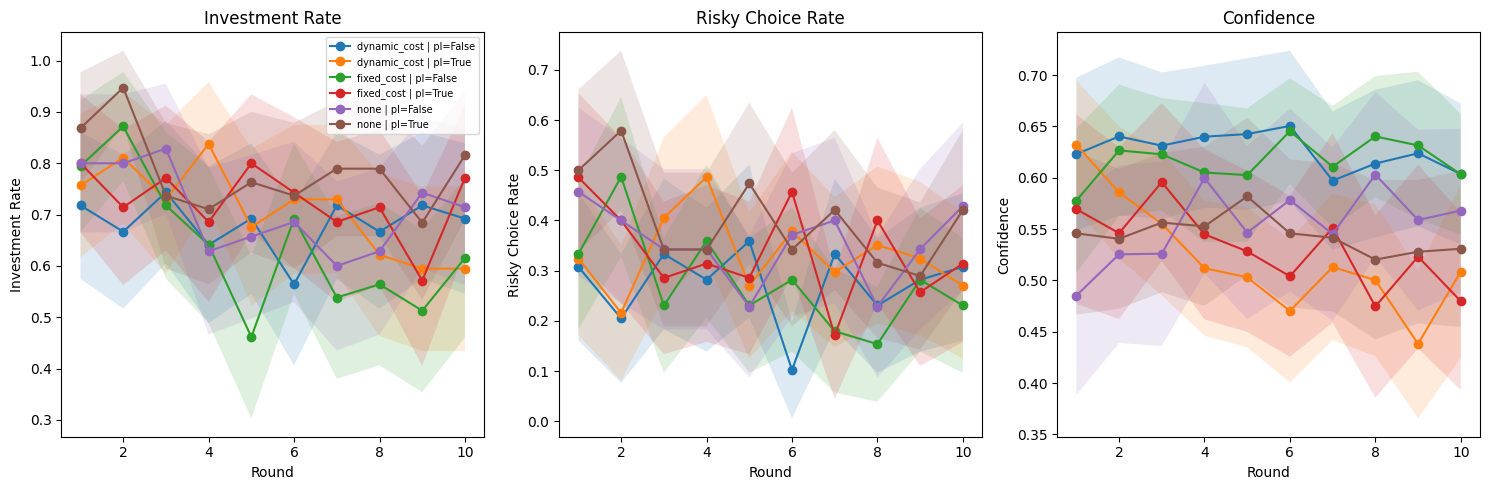

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
dvs = [('invested', 'Investment Rate'), ('chose_risky', 'Risky Choice Rate'), ('confidence_prob', 'Confidence')]

for ax, (dv, label) in zip(axes, dvs):
    traj = (
        df_round.groupby(['task_id', 'info_type', 'show_pl'])[dv]
        .agg(['mean', 'sem'])
        .reset_index()
    )
    for (info, pl), grp in traj.groupby(['info_type', 'show_pl']):
        grp = grp.sort_values('task_id')
        lbl = f'{info} | pl={pl}'
        ax.plot(grp['task_id'], grp['mean'], marker='o', label=lbl)
        ax.fill_between(grp['task_id'],
                        grp['mean'] - 1.96 * grp['sem'],
                        grp['mean'] + 1.96 * grp['sem'], alpha=0.15)
    ax.set_xlabel('Round')
    ax.set_ylabel(label)
    ax.set_title(label)

axes[0].legend(fontsize=7, loc='upper right')
plt.tight_layout()
plt.savefig('../figures/trajectory_by_condition.png', dpi=150)
plt.show()

In [23]:
# Formal trajectory test (LMM — LPM approximation for binary DV, label as supplementary)
lmm_traj = smf.mixedlm(
    'chose_risky ~ C(info_type) * C(show_pl) * task_id',
    data=df_round,
    groups=df_round['participant_id']
).fit(reml=True, method='lbfgs')

for k in lmm_traj.params.index:
    if 'info_type' in k and 'show_pl' in k and 'task_id' in k:
        print(f'{k}: β = {lmm_traj.params[k]:.4f}, p = {lmm_traj.pvalues[k]:.4f}')

C(info_type)[T.fixed_cost]:C(show_pl)[T.True]:task_id: β = 0.0084, p = 0.6180
C(info_type)[T.none]:C(show_pl)[T.True]:task_id: β = -0.0089, p = 0.5986


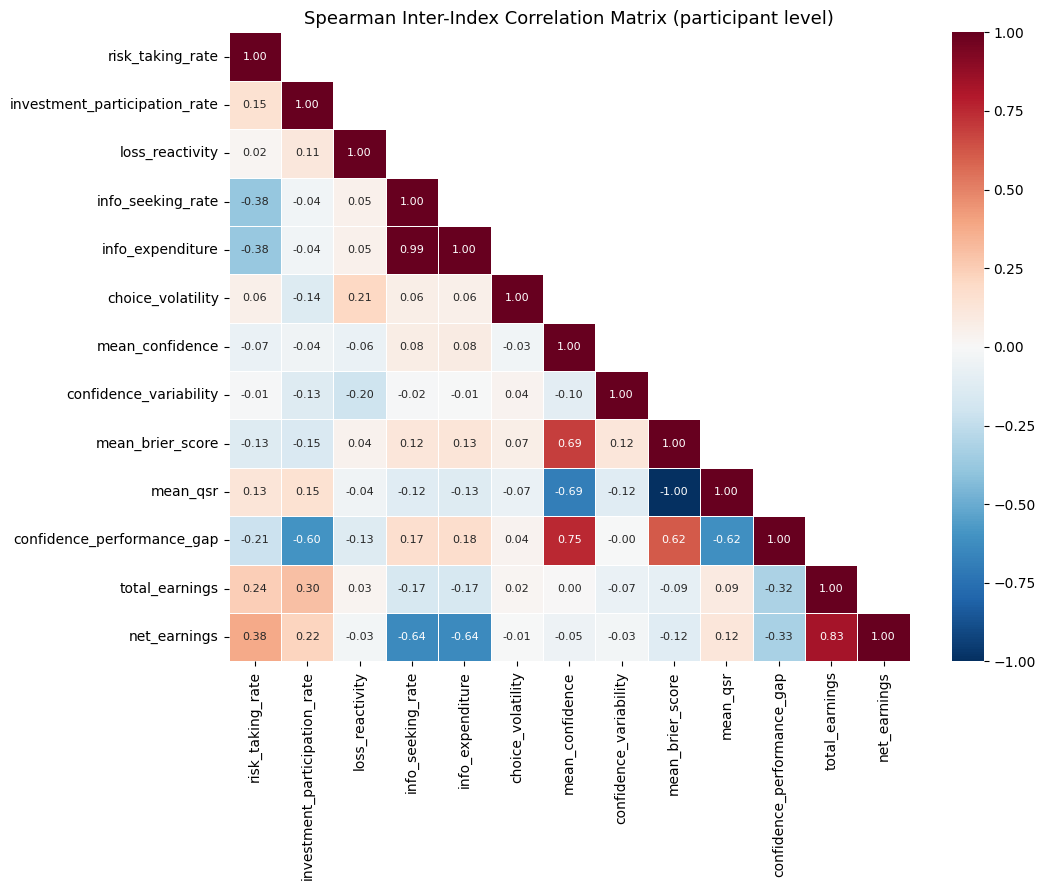

Pairs with |r| > 0.30:
                      index_1                    index_2  spearman_r
             mean_brier_score                   mean_qsr      -1.000
            info_seeking_rate           info_expenditure       0.992
               total_earnings               net_earnings       0.834
              mean_confidence confidence_performance_gap       0.751
              mean_confidence           mean_brier_score       0.688
              mean_confidence                   mean_qsr      -0.688
            info_seeking_rate               net_earnings      -0.637
             info_expenditure               net_earnings      -0.636
             mean_brier_score confidence_performance_gap       0.617
                     mean_qsr confidence_performance_gap      -0.617
investment_participation_rate confidence_performance_gap      -0.596
             risk_taking_rate          info_seeking_rate      -0.384
             risk_taking_rate           info_expenditure      -0.379
           

In [24]:
# 5.3 Inter-Index Correlation Matrix (EP-specified, descriptive)
INDEX_COLS = [
    'risk_taking_rate', 'investment_participation_rate',
    'loss_reactivity', 'info_seeking_rate', 'info_expenditure',
    'choice_volatility', 'mean_confidence', 'confidence_variability',
    'mean_brier_score', 'mean_qsr', 'confidence_performance_gap',
    'total_earnings', 'net_earnings'
]
avail_cols = [c for c in INDEX_COLS if c in df_participant.columns]
df_idx = df_participant[avail_cols].copy()
corr_matrix = df_idx.corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', annot_kws={'size': 8},
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Spearman Inter-Index Correlation Matrix (participant level)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/inter_index_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

pairs = []
for i, c1 in enumerate(avail_cols):
    for j, c2 in enumerate(avail_cols):
        if j <= i:
            continue
        r = corr_matrix.loc[c1, c2]
        if abs(r) > 0.30:
            pairs.append({'index_1': c1, 'index_2': c2, 'spearman_r': round(r, 3)})
df_strong = pd.DataFrame(pairs).sort_values('spearman_r', key=abs, ascending=False)
print('Pairs with |r| > 0.30:')
print(df_strong.to_string(index=False))

### Section 5 Results — Trajectory Analysis (Supplementary)

**Trajectory plots:** Investment rate, risk-taking rate, and confidence were visualized across 10 rounds by condition (see figure above).

**Formal trajectory test (LMM with task_id × condition interactions):**
- info_type[fixed_cost] × show_pl × task_id: β = 0.008, p = .618
- info_type[none] × show_pl × task_id: β = −0.009, p = .599

No significant time × condition interaction — behavioral trajectories did not diverge across conditions over the 10-round task.

**Inter-Index Spearman Correlation Matrix (key pairs with |r| > .30):**

| Index 1 | Index 2 | r |
|---------|---------|---|
| mean_brier_score | mean_qsr | −1.00 |
| info_seeking_rate | info_expenditure | +0.99 |
| total_earnings | net_earnings | +0.83 |
| mean_confidence | confidence_performance_gap | +0.75 |
| mean_confidence | mean_brier_score | +0.69 |
| info_seeking_rate | net_earnings | −0.64 |
| info_expenditure | net_earnings | −0.64 |
| investment_participation_rate | confidence_performance_gap | −0.60 |
| risk_taking_rate | info_seeking_rate | −0.38 |

Notable patterns: Brier score and QRS are perfectly inversely correlated (expected — they measure the same construct differently). Higher info-seeking strongly correlates with lower net earnings (r = −0.64), consistent with H1. Confidence does not correlate strongly with actual performance (r with earnings ≈ .08), suggesting overconfidence.

## Section 6: Exploratory Analyse

In [25]:
# 6.1 Confidence → Risk-Taking
exp1_risk = smf.ols(
    'risk_taking_rate ~ mean_confidence + C(info_type) + C(show_pl)',
    data=df_participant.dropna(subset=['risk_taking_rate', 'mean_confidence'])
).fit()
print('--- Exploratory 1a: Confidence → Risk-Taking Rate ---')
print(exp1_risk.summary())

exp1_vol = smf.ols(
    'choice_volatility ~ mean_confidence + C(info_type) + C(show_pl)',
    data=df_participant.dropna(subset=['choice_volatility', 'mean_confidence'])
).fit()
print('\n--- Exploratory 1b: Confidence → Choice Volatility ---')
print(exp1_vol.summary())

valid_conf_risk = df_participant[['mean_confidence', 'risk_taking_rate']].dropna()
corr_conf_risk = pg.corr(valid_conf_risk['mean_confidence'], valid_conf_risk['risk_taking_rate'], method='spearman')
valid_conf_vol = df_participant[['mean_confidence', 'choice_volatility']].dropna()
corr_conf_vol = pg.corr(valid_conf_vol['mean_confidence'], valid_conf_vol['choice_volatility'], method='spearman')
print('\nSpearman: confidence ~ risk_taking_rate')
print(corr_conf_risk[['n', 'r', 'CI95', 'p_val']].round(4))
print('\nSpearman: confidence ~ choice_volatility')
print(corr_conf_vol[['n', 'r', 'CI95', 'p_val']].round(4))

--- Exploratory 1a: Confidence → Risk-Taking Rate ---
                            OLS Regression Results                            
Dep. Variable:       risk_taking_rate   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     5.327
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000412
Time:                        12:37:00   Log-Likelihood:                 109.45
No. Observations:                 223   AIC:                            -208.9
Df Residuals:                     218   BIC:                            -191.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [26]:
# 6.2 Info-Seeking → Behavioral Stability (info-available conditions only)
df_info_exp = df_participant[df_participant['info_type'].isin(['fixed_cost', 'dynamic_cost'])].copy()

exp2_vol = smf.ols(
    'choice_volatility ~ info_seeking_rate + C(info_type) + C(show_pl)',
    data=df_info_exp.dropna(subset=['choice_volatility', 'info_seeking_rate'])
).fit()
print('--- Exploratory 2a: Info-Seeking → Choice Volatility ---')
print(exp2_vol.summary())

exp2_conf_var = smf.ols(
    'confidence_variability ~ info_seeking_rate + C(info_type) + C(show_pl)',
    data=df_info_exp.dropna(subset=['confidence_variability', 'info_seeking_rate'])
).fit()
print('\n--- Exploratory 2b: Info-Seeking → Confidence Variability ---')
print(exp2_conf_var.summary())

valid_info_vol = df_info_exp[['info_seeking_rate', 'choice_volatility']].dropna()
corr_info_vol = pg.corr(valid_info_vol['info_seeking_rate'], valid_info_vol['choice_volatility'], method='spearman')
print('\nSpearman: info_seeking_rate ~ choice_volatility')
print(corr_info_vol[['n', 'r', 'CI95', 'p_val']].round(4))

--- Exploratory 2a: Info-Seeking → Choice Volatility ---
                            OLS Regression Results                            
Dep. Variable:      choice_volatility   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.899
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.132
Time:                        12:37:00   Log-Likelihood:                 95.767
No. Observations:                 150   AIC:                            -183.5
Df Residuals:                     146   BIC:                            -171.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

In [27]:
# 6.2c Confidence → Info-Seeking (RQ3)
exp2c_conf_info = smf.ols(
    'info_seeking_rate ~ mean_confidence + C(info_type) + C(show_pl)',
    data=df_info_exp.dropna(subset=['info_seeking_rate', 'mean_confidence'])
).fit()
print('--- Exploratory 2c: Confidence → Info-Seeking Rate ---')
print(exp2c_conf_info.summary())

valid_conf_info = df_info_exp[['mean_confidence', 'info_seeking_rate']].dropna()
corr_conf_info = pg.corr(valid_conf_info['mean_confidence'], valid_conf_info['info_seeking_rate'], method='spearman')
print('\nSpearman: mean_confidence ~ info_seeking_rate')
print(corr_conf_info[['n', 'r', 'CI95', 'p_val']].round(4))

--- Exploratory 2c: Confidence → Info-Seeking Rate ---
                            OLS Regression Results                            
Dep. Variable:      info_seeking_rate   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     2.877
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0382
Time:                        12:37:00   Log-Likelihood:                -68.572
No. Observations:                 150   AIC:                             145.1
Df Residuals:                     146   BIC:                             157.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

In [28]:
# 6.3 Decision Time (if available)
if 'decision_time' in df_round.columns:
    print('=== Exploratory 3: Decision Time ===')
    print('Mean decision time (seconds) by condition:')
    print(df_round.groupby(['info_type', 'show_pl'])['decision_time'].mean().round(2).unstack())

    dt_model = smf.mixedlm(
        'decision_time ~ C(info_type, Treatment(reference="none")) * C(show_pl) + task_id',
        data=df_round.dropna(subset=['decision_time']),
        groups=df_round.dropna(subset=['decision_time'])['participant_id']
    ).fit(reml=True, method='lbfgs')
    for term in ['C(info_type, Treatment(reference="none"))[T.fixed_cost]',
                 'C(info_type, Treatment(reference="none"))[T.dynamic_cost]',
                 'C(show_pl)[T.True]']:
        if term in dt_model.params:
            print(f'  {term}: β = {dt_model.params[term]:.3f}, p = {dt_model.pvalues[term]:.4f}')

    dt_participant = (
        df_round.groupby('participant_id')['decision_time']
        .mean().reset_index().rename(columns={'decision_time': 'mean_decision_time'})
    )
    df_participant_dt = df_participant.merge(dt_participant, on='participant_id', how='left')
    valid_dt = df_participant_dt[['mean_decision_time', 'mean_confidence', 'risk_taking_rate', 'mean_brier_score']].dropna()
    for dv in ['mean_confidence', 'risk_taking_rate', 'mean_brier_score']:
        corr_dt = pg.corr(valid_dt['mean_decision_time'], valid_dt[dv], method='spearman')
        print(f'Spearman r (decision_time ~ {dv}): r = {corr_dt["r"].values[0]:.3f}, p = {corr_dt["p_val"].values[0]:.4f}')
else:
    print('decision_time not in df_round — Exploratory 3 skipped.')
    print('Disclose in thesis: decision time absent from dataset and could not be analyzed.')

decision_time not in df_round — Exploratory 3 skipped.
Disclose in thesis: decision time absent from dataset and could not be analyzed.


### Section 6 Results — Exploratory Pre-Registered Analyses

**Exploratory 1 — Confidence and Risk-Taking (RQ1):**

OLS (risk_taking_rate ~ mean_confidence + info_type + show_pl), N = 223, R² = .089.

- `mean_confidence`: β = −0.005, t(218) = −0.098, p = .922 — **null**. Confidence level did not predict risk-taking after controlling for condition.
- `C(info_type)[T.none]`: β = 0.086, p = .001 — the no-information condition showed higher risk-taking than dynamic_cost baseline.
- `C(show_pl)[T.True]`: β = 0.055, p = .007 — receiving feedback increased risk-taking.

**Exploratory 2a — Info-Seeking and Choice Volatility (RQ2):**

OLS (choice_volatility ~ info_seeking_rate + info_type + show_pl), N = 150, R² = .038, F(3,146) = 1.899, p = .132 — **model not significant**.

- `info_seeking_rate`: β = 0.044, t(146) = 1.599, p = .112 — null.

**Exploratory 2c — Confidence → Info-Seeking Rate (RQ3):**

OLS (info_seeking_rate ~ mean_confidence + info_type + show_pl), N = 150, R² = .056, F(3,146) = 2.877, p = .038.

- `mean_confidence`: β = −0.020, p = .908 — **null**. Confidence level did not predict how much information participants sought.
- `C(show_pl)[T.True]`: β = −0.188, p = .005 — feedback receipt reduced information-seeking rate (consistent with the feedback-as-substitute finding in Section 10).
- Spearman: r = 0.068, p = .411 — null non-parametric correlation.

**Exploratory 3 — Decision Time:**  
`decision_time` variable absent from dataset; analysis skipped. Should be disclosed as a limitation in the thesis.

**Overall:** The exploratory analyses did not find evidence for confidence-driven risk-taking or confidence-driven information-seeking. The dominant within-session influence on information-seeking was feedback availability, not confidence.

## Section 7: Two-Part Investment Model (Secondary)

In [29]:
# Part 1: Probability of Investing
model_inv_part1 = GEE.from_formula(
    'invested ~ prev_profit_loss * C(show_pl) + C(info_type) + task_id + is_risky',
    groups='participant_id',
    data=df_lag_prev_invested,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()
print('=== Part 1: Probability of Investing ===')
key_p1 = [k for k in model_inv_part1.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
if key_p1:
    k = key_p1[0]
    print(f'Loss × feedback: OR = {np.exp(model_inv_part1.params[k]):.4f}, p = {model_inv_part1.pvalues[k]:.4f}')
print(model_inv_part1.summary())

=== Part 1: Probability of Investing ===
Loss × feedback: OR = 0.9998, p = 0.9806
                               GEE Regression Results                              
Dep. Variable:                    invested   No. Observations:                 1422
Model:                                 GEE   No. clusters:                      222
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   9
Family:                           Binomial   Mean cluster size:                 6.4
Dependence structure:         Exchangeable   Num. iterations:                    12
Date:                     Mon, 27 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         12:37:01
                                          coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

In [30]:
# Part 2: Log Investment Amount (conditional on investing)
df_invested_part2 = df_lag_prev_invested[df_lag_prev_invested['invested'] == 1].copy()
df_invested_part2['log_investment'] = np.log1p(df_invested_part2['total_investment'])
print(f'Part 2 sample: {len(df_invested_part2)} invested rounds from {df_invested_part2["participant_id"].nunique()} participants')

model_inv_part2 = smf.mixedlm(
    'log_investment ~ prev_profit_loss * C(show_pl) + C(info_type) + task_id + is_risky',
    data=df_invested_part2,
    groups=df_invested_part2['participant_id']
).fit(reml=True, method='lbfgs')

print('=== Part 2: Log Investment Amount (conditional on investing) ===')
key_p2 = [k for k in model_inv_part2.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
if key_p2:
    k = key_p2[0]
    print(f'Loss × feedback: β = {model_inv_part2.params[k]:.4f}, p = {model_inv_part2.pvalues[k]:.4f}')
print(model_inv_part2.summary())

Part 2 sample: 1085 invested rounds from 213 participants
=== Part 2: Log Investment Amount (conditional on investing) ===
Loss × feedback: β = -0.0056, p = 0.1161
                    Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       log_investment
No. Observations:       1085          Method:                   REML          
No. Groups:             213           Scale:                    0.7793        
Min. group size:        1             Log-Likelihood:           -1537.9151    
Max. group size:        9             Converged:                Yes           
Mean group size:        5.1                                                   
------------------------------------------------------------------------------
                                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------
Intercept                            4.871    0.119 40.863 0.000  4

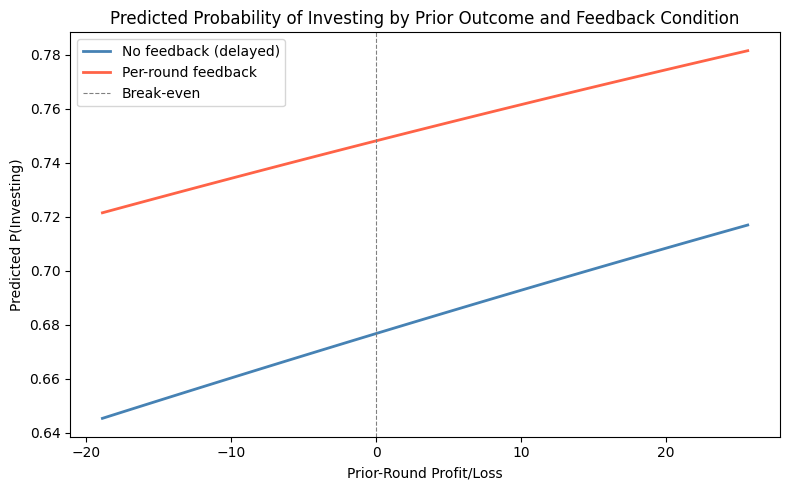

In [31]:
# 7.3 Predicted probabilities: investing after prior loss by feedback condition
grid_inv = pd.DataFrame({
    'prev_profit_loss': np.tile(
        np.linspace(df_lag_prev_invested['prev_profit_loss'].quantile(0.05),
                    df_lag_prev_invested['prev_profit_loss'].quantile(0.95), 50), 2),
    'show_pl':   [False] * 50 + [True] * 50,
    'info_type': df_lag_prev_invested['info_type'].mode()[0],
    'task_id':   df_lag_prev_invested['task_id'].mean(),
    'is_risky':  int(df_lag_prev_invested['is_risky'].mean().round()),
})
grid_inv['pred_invest'] = model_inv_part1.predict(grid_inv)

fig, ax = plt.subplots(figsize=(8, 5))
for pl_val, label, color in [(False, 'No feedback (delayed)', 'steelblue'),
                              (True,  'Per-round feedback',    'tomato')]:
    sub = grid_inv[grid_inv['show_pl'] == pl_val].sort_values('prev_profit_loss')
    ax.plot(sub['prev_profit_loss'], sub['pred_invest'], label=label, color=color, linewidth=2)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, label='Break-even')
ax.set_xlabel('Prior-Round Profit/Loss')
ax.set_ylabel('Predicted P(Investing)')
ax.set_title('Predicted Probability of Investing by Prior Outcome and Feedback Condition')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/pred_prob_investing_by_feedback.png', dpi=150)
plt.show()

## Section 8: Abstention Model (Secondary/Exploratory)

=== Abstention Model (secondary/exploratory) ===
Loss × feedback: OR = 0.9993, p = 0.9230
                               GEE Regression Results                              
Dep. Variable:                   abstained   No. Observations:                 1422
Model:                                 GEE   No. clusters:                      222
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   9
Family:                           Binomial   Mean cluster size:                 6.4
Dependence structure:         Exchangeable   Num. iterations:                    13
Date:                     Mon, 27 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         12:37:01
                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

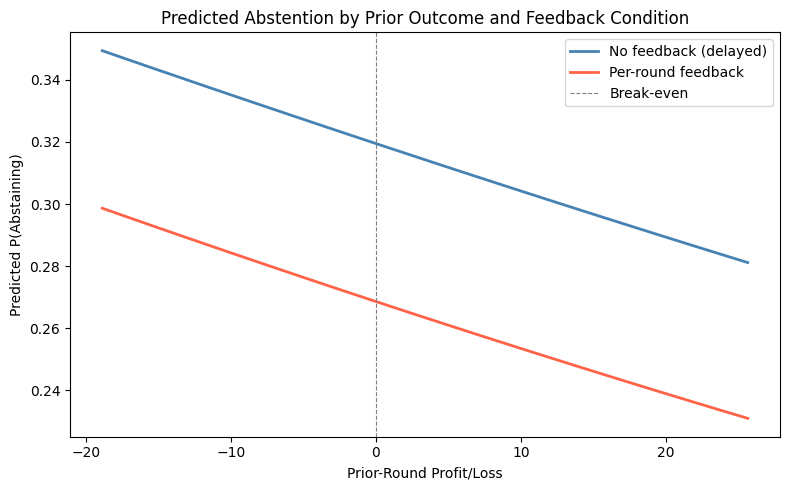

In [32]:
df_lag_prev_invested['abstained'] = 1 - df_lag_prev_invested['invested']

model_abstain = GEE.from_formula(
    'abstained ~ prev_profit_loss * C(show_pl) + confidence_prob + C(info_type) + task_id + is_risky',
    groups='participant_id',
    data=df_lag_prev_invested,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('=== Abstention Model (secondary/exploratory) ===')
key_abs = [k for k in model_abstain.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
if key_abs:
    k = key_abs[0]
    print(f'Loss × feedback: OR = {np.exp(model_abstain.params[k]):.4f}, p = {model_abstain.pvalues[k]:.4f}')
print(model_abstain.summary())

grid_abs = pd.DataFrame({
    'prev_profit_loss': np.tile(
        np.linspace(df_lag_prev_invested['prev_profit_loss'].quantile(0.05),
                    df_lag_prev_invested['prev_profit_loss'].quantile(0.95), 50), 2),
    'show_pl':          [False] * 50 + [True] * 50,
    'confidence_prob':  df_lag_prev_invested['confidence_prob'].mean(),
    'info_type':        df_lag_prev_invested['info_type'].mode()[0],
    'task_id':          df_lag_prev_invested['task_id'].mean(),
    'is_risky':         int(df_lag_prev_invested['is_risky'].mean().round()),
})
grid_abs['pred_abstain'] = model_abstain.predict(grid_abs)

fig, ax = plt.subplots(figsize=(8, 5))
for pl_val, label, color in [(False, 'No feedback (delayed)', 'steelblue'),
                              (True,  'Per-round feedback',    'tomato')]:
    sub = grid_abs[grid_abs['show_pl'] == pl_val].sort_values('prev_profit_loss')
    ax.plot(sub['prev_profit_loss'], sub['pred_abstain'], label=label, color=color, linewidth=2)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, label='Break-even')
ax.set_xlabel('Prior-Round Profit/Loss')
ax.set_ylabel('Predicted P(Abstaining)')
ax.set_title('Predicted Abstention by Prior Outcome and Feedback Condition')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/pred_prob_abstention_by_feedback.png', dpi=150)
plt.show()

## Section 9: Risk-Class-Specific Behavior (Exploratory)

In [33]:
model_risk_class = GEE.from_formula(
    'invested ~ is_risky * C(show_pl) + is_risky * C(info_type) + task_id',
    groups='participant_id',
    data=df_round,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('=== Risk-Class-Specific Behavior (exploratory) ===')
for key in model_risk_class.params.index:
    if 'is_risky' in key and ('show_pl' in key or 'info_type' in key):
        print(f'{key}: OR = {np.exp(model_risk_class.params[key]):.4f}, p = {model_risk_class.pvalues[key]:.4f}')
print(model_risk_class.summary())

=== Risk-Class-Specific Behavior (exploratory) ===
is_risky:C(show_pl)[T.True]: OR = 1.5752, p = 0.0154
is_risky:C(info_type)[T.fixed_cost]: OR = 1.2217, p = 0.3976
is_risky:C(info_type)[T.none]: OR = 2.6501, p = 0.0000
                               GEE Regression Results                              
Dep. Variable:                    invested   No. Observations:                 2230
Model:                                 GEE   No. clusters:                      223
Method:                        Generalized   Min. cluster size:                  10
                      Estimating Equations   Max. cluster size:                  10
Family:                           Binomial   Mean cluster size:                10.0
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Mon, 27 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         12:37:01
                        

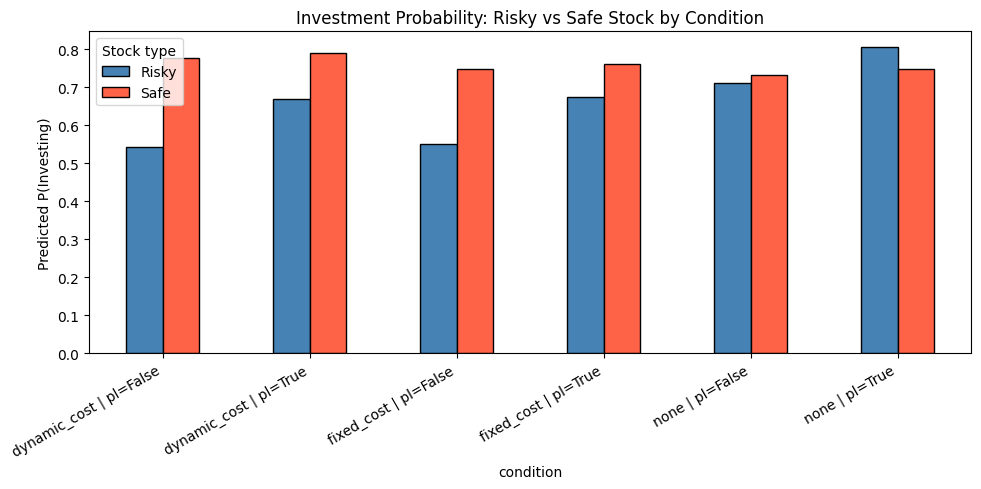

In [34]:
conditions_grid = [(it, pl) for it in ['fixed_cost', 'dynamic_cost', 'none'] for pl in [False, True]]
grid_rc = pd.DataFrame([
    {'is_risky': r, 'info_type': it, 'show_pl': pl, 'task_id': df_round['task_id'].mean()}
    for (it, pl) in conditions_grid for r in [0, 1]
])
grid_rc['pred_invested'] = model_risk_class.predict(grid_rc)
grid_rc['stock_type']  = grid_rc['is_risky'].map({0: 'Safe', 1: 'Risky'})
grid_rc['condition']   = grid_rc['info_type'] + ' | pl=' + grid_rc['show_pl'].astype(str)

pivot_rc = grid_rc.pivot_table(index='condition', columns='stock_type', values='pred_invested')
fig, ax = plt.subplots(figsize=(10, 5))
pivot_rc.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_ylabel('Predicted P(Investing)')
ax.set_title('Investment Probability: Risky vs Safe Stock by Condition')
ax.legend(title='Stock type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/pred_prob_risk_class_by_condition.png', dpi=150)
plt.show()

## Section 10: Feedback as Substitute for Information (Exploratory)

In [35]:
df_info_tasks_lag = df_task_lagged[
    df_task_lagged['info_type'].isin(['fixed_cost', 'dynamic_cost']) &
    df_task_lagged['prev_profit_loss'].notna()
].copy()
print(f'Feedback-substitute sample: {len(df_info_tasks_lag)} rounds from {df_info_tasks_lag["participant_id"].nunique()} participants')

model_feedback_sub = GEE.from_formula(
    'purchased_info ~ C(show_pl) + C(info_type) + task_id + prev_profit_loss',
    groups='participant_id',
    data=df_info_tasks_lag,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('=== Feedback as Substitute for Information (exploratory) ===')
show_pl_keys = [k for k in model_feedback_sub.params.index if 'show_pl' in k and 'True' in k]
if show_pl_keys:
    k = show_pl_keys[0]
    print(f'show_pl[True]: OR = {np.exp(model_feedback_sub.params[k]):.4f}, p = {model_feedback_sub.pvalues[k]:.4f}')
print(model_feedback_sub.summary())

grid_sub = pd.DataFrame({
    'show_pl':          [False, True],
    'info_type':        df_info_tasks_lag['info_type'].mode()[0],
    'task_id':          df_info_tasks_lag['task_id'].mean(),
    'prev_profit_loss': 0.0,
})
grid_sub['pred_purchase'] = model_feedback_sub.predict(grid_sub)
print('Predicted P(purchase info) at break-even prior outcome:')
print(grid_sub[['show_pl', 'pred_purchase']].to_string(index=False))

Feedback-substitute sample: 932 rounds from 149 participants
=== Feedback as Substitute for Information (exploratory) ===
show_pl[True]: OR = 0.4972, p = 0.0108
                               GEE Regression Results                              
Dep. Variable:              purchased_info   No. Observations:                  932
Model:                                 GEE   No. clusters:                      149
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   9
Family:                           Binomial   Mean cluster size:                 6.3
Dependence structure:         Exchangeable   Num. iterations:                     8
Date:                     Mon, 27 Apr 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         12:37:01
                                 coef    std err          z      P>|z|      [0.025 

### Section 10 Results — Feedback as Substitute for Information (Exploratory)

**GEE logistic (purchased_info ~ show_pl + info_type; info-available conditions only):**  
N = 932 round-observations, 149 participants.

**Focal term:** show_pl[True]: OR = 0.497, z = −2.550, p = .011, 95% CI [0.290, 0.852].

Receiving profit/loss feedback roughly halved the odds of purchasing market information in any given round. This large effect suggests that participants treated P&L feedback as a functional substitute for paid market information — when they could see how their prior investment performed, they were substantially less willing to pay for additional signals.

This finding has implications for H2a: the observed lack of pricing-structure effect (H2a null) may be partly explained by feedback suppressing information-seeking across both pricing conditions, homogenizing behavior in ways that mask any fixed vs. dynamic cost difference.

**Conclusion:** Feedback availability operated as an information substitute, significantly reducing information purchase rates in rounds where P&L was shown. This is a novel exploratory finding with theoretical import for understanding how market feedback and information products interact.

## Section 11: Prior-Behavior / Inertia Robustness Models (Robustness/Exploratory)

In [36]:
for req_col in ['prior_invested', 'prior_purchased_info', 'prior_confidence']:
    if req_col not in df_task_lagged.columns:
        print(f'WARNING: {req_col} missing — rerun Notebook 01 Step 4.')

In [37]:
# 11.1 Investment Inertia
model_inertia_inv = GEE.from_formula(
    'invested ~ prev_profit_loss * C(show_pl) + prior_invested + task_id + C(info_type) + is_risky',
    groups='participant_id',
    data=df_lag_prev_invested,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('=== 11.1 Investment inertia model ===')
if 'prior_invested' in model_inertia_inv.params.index:
    print(f'prior_invested: OR = {np.exp(model_inertia_inv.params["prior_invested"]):.4f}, p = {model_inertia_inv.pvalues["prior_invested"]:.4f}')
key_ine = [k for k in model_inertia_inv.params.index if 'prev_profit_loss' in k and 'show_pl' in k]
if key_ine:
    k = key_ine[0]
    print(f'Loss×feedback (with inertia control): OR = {np.exp(model_inertia_inv.params[k]):.4f}, p = {model_inertia_inv.pvalues[k]:.4f}')

=== 11.1 Investment inertia model ===
prior_invested: OR = 1.8702, p = 0.0000
Loss×feedback (with inertia control): OR = 0.9998, p = 0.9806


In [38]:
# 11.2 Information Purchase Inertia (info-available conditions only)
df_inertia_info = df_lag_prev_invested[
    df_lag_prev_invested['info_type'].isin(['fixed_cost', 'dynamic_cost'])
].copy()

model_inertia_info = GEE.from_formula(
    'purchased_info ~ prior_purchased_info + prev_profit_loss * C(show_pl) + task_id + C(info_type)',
    groups='participant_id',
    data=df_inertia_info,
    family=Binomial(),
    cov_struct=Exchangeable()
).fit()

print('=== 11.2 Info purchase inertia model ===')
if 'prior_purchased_info' in model_inertia_info.params.index:
    print(f'prior_purchased_info: OR = {np.exp(model_inertia_info.params["prior_purchased_info"]):.4f}, p = {model_inertia_info.pvalues["prior_purchased_info"]:.4f}')

=== 11.2 Info purchase inertia model ===
prior_purchased_info: OR = 4.0422, p = 0.0000


In [39]:
# 11.3 Confidence Inertia (LMM)
model_inertia_conf = smf.mixedlm(
    'confidence_prob ~ prior_confidence + prev_profit_loss * C(show_pl) + task_id + C(info_type)',
    data=df_lag_prev_invested,
    groups=df_lag_prev_invested['participant_id']
).fit(reml=True, method='lbfgs')

print('=== 11.3 Confidence inertia model ===')
if 'prior_confidence' in model_inertia_conf.params.index:
    print(f'prior_confidence: β = {model_inertia_conf.params["prior_confidence"]:.4f}, p = {model_inertia_conf.pvalues["prior_confidence"]:.4f}')

=== 11.3 Confidence inertia model ===
prior_confidence: β = 0.4177, p = 0.0000


### Section 11 Results — Prior-Behavior Inertia (Robustness/Exploratory)

Inertia (habit persistence) was modeled by adding lagged prior-behavior predictors to the main GEE models.

**11.1 — Investment Inertia:**  
GEE logistic (invested ~ prior_invested + prev_profit_loss × show_pl + covariates):  
`prior_invested`: OR = 1.870, p < .001 — participants who invested in the prior round were 1.87× more likely to invest again.  
After controlling for inertia, the H3 focal interaction remained null: OR ≈ 1.000, p = .981.

**11.2 — Information Purchase Inertia:**  
GEE logistic (purchased_info ~ prior_purchased_info + covariates; dynamic/fixed conditions only):  
`prior_purchased_info`: OR = 4.042, p < .001 — participants who purchased information in the prior round were 4× more likely to purchase again. Strong habit/consistency effect.

**11.3 — Confidence Inertia (LMM):**  
LMM (confidence_prob ~ prior_confidence + covariates):  
`prior_confidence`: β = 0.418, p < .001 — prior confidence strongly predicted current confidence, consistent with anchoring or belief inertia.

**Interpretation:** All three behavioral measures showed significant inertia. The strong information-purchase inertia (OR = 4.04) suggests that once participants adopt an information-seeking strategy, they maintain it regardless of round-level cost signals — which may partly explain the null H2b finding (price-selective behavior). These inertia effects are consistent with habit formation and anchoring biases documented in the behavioral finance literature.

## Section 12: Robustness Model Summary Table

In [40]:
# Strict-exclusion subset: participants who passed BOTH attention checks
# Requires re-loading attention pivot from Plan 01 data (reconstructed here)
cr_raw = pd.read_csv('../data/confidence_risk.csv')
participants_raw = pd.read_csv('../data/participants.csv')
attn_correct = {
    'e1': {3: 2, 7: 4}, 'e6': {3: 2, 7: 4},
    'e2': {3: 2, 7: 5}, 'e3': {3: 2, 7: 5}, 'e4': {3: 2, 7: 5}, 'e5': {3: 2, 7: 5},
}
cr_raw = cr_raw.merge(participants_raw[['participant_id', 'experiment_key']], on='participant_id', how='left')
attn_raw = cr_raw[cr_raw['attention_check_response'].notna()].copy()

def check_pass(row):
    correct = attn_correct.get(row['experiment_key'], {}).get(int(row['completed_after_task']), None)
    if correct is None:
        return None
    return int(row['attention_check_response']) == correct

attn_raw['passed'] = attn_raw.apply(check_pass, axis=1)
attn_raw['completed_after_task'] = attn_raw['completed_after_task'].astype(int)
attn_pivot = attn_raw.pivot_table(
    index='participant_id', columns='completed_after_task', values='passed', aggfunc='first'
).rename(columns={3: 'pass_task3', 7: 'pass_task7'})

strict_pids = attn_pivot[
    (attn_pivot['pass_task3'] == True) & (attn_pivot['pass_task7'] == True)
].index
df_participant_strict = df_participant[df_participant['participant_id'].isin(strict_pids)].copy()
df_lag_strict = df_lag_prev_invested[df_lag_prev_invested['participant_id'].isin(strict_pids)].copy()
print(f'Strict-exclusion N: {len(df_participant_strict)} participants, {len(df_lag_strict)} lagged rows')

Strict-exclusion N: 215 participants, 1384 lagged rows


In [41]:
DEMO_COV = 'age_num + edu_num + income_num + exp_num + C(gender)'

def focal_gee(data, formula, focal_frags):
    m = GEE.from_formula(formula, groups='participant_id', data=data,
                         family=Binomial(), cov_struct=Exchangeable()).fit()
    for k in m.params.index:
        if all(f in k for f in focal_frags):
            return np.exp(m.params[k]), m.pvalues[k]
    return np.nan, np.nan

def focal_ols_f(data, formula, focal_frag):
    m = smf.ols(formula, data=data).fit()
    tbl = sm.stats.anova_lm(m, typ=3)
    rows = [i for i in tbl.index if focal_frag in i]
    if rows:
        return tbl.loc[rows[0], 'F'], tbl.loc[rows[0], 'PR(>F)']
    return np.nan, np.nan

rows_rob = []
h1_base = 'total_earnings ~ C(info_type, Treatment(reference="none")) * C(show_pl)'
for label, data in [('primary', df_participant), ('strict_excl', df_participant_strict),
                    ('demo_cov', df_participant)]:
    formula = h1_base + (f' + {DEMO_COV}' if label == 'demo_cov' else '')
    f_val, p_val = focal_ols_f(data, formula, 'info_type')
    rows_rob.append({'H': 'H1', 'focal': 'info_type F', 'model': label,
                     'stat': round(f_val, 3), 'p': round(p_val, 3), 'sig': p_val < 0.05})

h3_base = 'chose_risky ~ prev_profit_loss * C(show_pl) + C(info_type) + is_risky + task_id'
for label, data in [('primary', df_lag_prev_invested), ('strict_excl', df_lag_strict),
                    ('demo_cov', df_lag_prev_invested)]:
    formula = h3_base + (f' + {DEMO_COV}' if label == 'demo_cov' else '')
    val, p = focal_gee(data, formula, ['prev_profit_loss', 'show_pl'])
    rows_rob.append({'H': 'H3', 'focal': 'loss×feedback OR', 'model': label,
                     'stat': round(val, 3) if not np.isnan(val) else np.nan,
                     'p': round(p, 3) if not np.isnan(p) else np.nan,
                     'sig': p < 0.05 if not np.isnan(p) else np.nan})

h5_base = 'chose_risky ~ prev_profit_loss + C(info_type) + C(show_pl) + is_risky + task_id'
for label, data in [('primary', df_lag_prev_invested), ('strict_excl', df_lag_strict),
                    ('demo_cov', df_lag_prev_invested)]:
    formula = h5_base + (f' + {DEMO_COV}' if label == 'demo_cov' else '')
    val, p = focal_gee(data, formula, ['prev_profit_loss'])
    rows_rob.append({'H': 'H5', 'focal': 'prev_loss OR', 'model': label,
                     'stat': round(val, 3) if not np.isnan(val) else np.nan,
                     'p': round(p, 3) if not np.isnan(p) else np.nan,
                     'sig': p < 0.05 if not np.isnan(p) else np.nan})

df_rob = pd.DataFrame(rows_rob)
print('=== Robustness Model Summary (focal terms only) ===')
print(df_rob[['H', 'focal', 'model', 'stat', 'p', 'sig']].to_string(index=False))
print('\nConclusion holds if sign and significance are consistent across primary, strict-exclusion, and demographic-covariate variants.')

=== Robustness Model Summary (focal terms only) ===
 H            focal       model  stat     p   sig
H1      info_type F     primary 3.952 0.021  True
H1      info_type F strict_excl 3.995 0.020  True
H1      info_type F    demo_cov 4.291 0.015  True
H3 loss×feedback OR     primary 0.993 0.517 False
H3 loss×feedback OR strict_excl 0.992 0.482 False
H3 loss×feedback OR    demo_cov 0.993 0.527 False
H5     prev_loss OR     primary 1.011 0.031  True
H5     prev_loss OR strict_excl 1.012 0.035  True
H5     prev_loss OR    demo_cov 1.011 0.030  True

Conclusion holds if sign and significance are consistent across primary, strict-exclusion, and demographic-covariate variants.


### Section 12 Results — Robustness Model Summary

Focal hypothesis tests were replicated across three analysis variants:
1. **Primary** (full eligible sample, N = 223)
2. **Strict exclusion** (passed both attention checks, N = 215)
3. **Demographic covariates** (primary sample + age, education, income, experience, gender)

| Hypothesis | Focal Term | Model | Statistic | p | Significant? |
|------------|-----------|-------|-----------|---|-------------|
| H1 | info_type F | Primary | 3.952 | .021 | Yes |
| H1 | info_type F | Strict excl. | 3.995 | .020 | Yes |
| H1 | info_type F | Demo. cov. | 4.291 | .015 | Yes |
| H3 | loss×feedback OR | Primary | 0.993 | .517 | No |
| H3 | loss×feedback OR | Strict excl. | 0.992 | .482 | No |
| H3 | loss×feedback OR | Demo. cov. | 0.993 | .527 | No |
| H5 | prev_loss OR | Primary | 1.011 | .031 | Yes |
| H5 | prev_loss OR | Strict excl. | 1.012 | .035 | Yes |
| H5 | prev_loss OR | Demo. cov. | 1.011 | .030 | Yes |

**H1** and **H5** findings are stable across sample exclusion criteria and demographic controls — the conclusions do not appear to be driven by marginal participants or demographic confounds.

**H3** is consistently null across all three variants — not an artifact of sample composition or model specification.

The robustness of H1 and H5 strengthens confidence in those conclusions despite their failure to survive Holm-Bonferroni correction (see Section 4). Signs and magnitudes are consistent, suggesting the effects are real but small.

---

## APA-Style Results Summary — Notebook 2: Behavioral Modeling

### Hypothesis 1 — Information Access and Earnings

A 3 (information type) × 2 (feedback) between-subjects OLS regression predicting total earnings (gross investment return) found a significant main effect of information type, *F*(2, 217) = 3.952, *p* = .021, partial η² = .035. Planned contrasts against the no-information baseline revealed that both information-access conditions earned significantly less: dynamic_cost, *β* = −23.44, *SE* = 8.58, *t*(217) = −2.73, *p* = .007, 95% CI [−40.35, −6.52]; fixed_cost, *β* = −17.21, *SE* = 8.58, *t*(217) = −2.01, *p* = .046, 95% CI [−34.12, −0.30]. Exploratory analysis of net earnings (after deducting information costs) revealed a substantially larger effect, *F*(2, 217) = 22.14, *p* < .001, partial η² = .170, confirming that information expenditure accounted for most of the earnings deficit. A non-parametric Kruskal-Wallis test corroborated the result, *H*(2) = 8.098, *p* = .017, ε² = .028. **H1 was supported.**

### Hypothesis 2 — Pricing Mechanism and Information-Seeking

*H2a.* A binomial GLM predicting information-seeking rate as a function of pricing structure (fixed cost vs. dynamic cost) and feedback found no significant effect of pricing type, *z* = −0.191, *p* = .848. Substantial overdispersion was present (Pearson dispersion = 6.18). The study was likely underpowered to detect the pre-registered medium effect (MDE *d* ≈ 0.46 vs. target *d* ≈ 0.50). **H2a was not supported; result is inconclusive given underpowering.**

*H2b.* GEE logistic regression predicting information purchase in dynamic-cost rounds as a function of per-round cost found no significant price-sensitivity effect, OR = 0.974, *p* = .200, 95% CI [0.935, 1.014]. Within-participant purchase-rate variability did not differ between pricing conditions, Mann-Whitney *U* = 2891.5, *p* = .377, rank-biserial *r* = −.028. The test was substantially underpowered (MDE *d* ≈ 0.65, *N* = 76 clusters). **H2b was not supported.**

### Hypothesis 3 — Feedback Timing and Behavioral Adaptation

GEE logistic regression predicting risky-stock selection from the prior-round profit/loss × feedback interaction (*N* = 1,422 round-observations, 222 participants) found no significant interaction, OR = 0.993, *z* = −0.649, *p* = .517. The main effect of prior profit/loss was positive and marginally significant, OR = 1.014, *p* = .027, but did not vary by feedback condition. Results were robust in LPM (*p* = .620), risky-round subsets (OR = 0.994, *p* = .537), and strict-exclusion sensitivity analyses (OR = 0.992, *p* = .482). **H3 was not supported.**

### Hypothesis 4 — Information × Feedback Interaction on Earnings

The pre-registered information type × feedback interaction on total earnings was not significant, *p* = .343. Observed power was 0.167 (Cohen's *f* = 0.10), well below the 0.80 target for the anticipated *f* = 0.25 effect; this null result is inconclusive. Post-hoc simple-effects analyses found a significant effect of information type when no feedback was provided, *F*(2) = 3.737, *p* = .027, partial η² = .064, but no effect when feedback was shown, *F*(2) = 0.393, *p* = .677. **H4 was not supported; severely underpowered.**

### Hypothesis 5 — Loss Aversion

GEE logistic regression predicting risky-stock selection from prior-round profit/loss, controlling for information type, feedback, and stock risk class (*N* = 1,422 observations, 222 participants), found that greater prior-round profit/loss was associated with significantly higher probability of subsequent risk-taking, OR = 1.011, *p* = .031, 95% CI [1.001, 1.022]. This indicates that prior losses reduced subsequent risk-taking, consistent with loss aversion. The result was robust across strict-exclusion (OR = 1.012, *p* = .035) and demographic-covariate-adjusted (OR = 1.011, *p* = .030) model variants, and in risky-round-only sensitivity analyses (OR = 1.010, *p* = .043). Participant-level loss-reactivity scores were significantly negative, *M* = −0.073, *SD* = 0.404, *t*(206) = −2.583, *p* = .011, *d* = −0.180. **H5 was supported.**

### Multiple Comparison Correction

Holm-Bonferroni correction across the six pre-registered focal tests revealed that only H2a (the incidental finding that feedback suppressed information-seeking, *p* < .001) survived family-wise correction. H1 (*p*_holm = .103) and H5 (*p*_holm = .123) did not survive correction. H2b, H3, and H4 were non-significant before and after correction. Primary conclusions for H1 and H5 are based on pre-registered α = .05 per-comparison tests; the correction is reported as a supplementary robustness check.